# **Emotional Risks and Ethical Challenges in AI Companionship**

## Supplementary Computational Appendix

This notebook documents the computational workflow used to construct and analyze a 25,000-conversation corpus of companionship-related interactions from `allenai/WildChat`.

It is intended to accompany the thesis as a reproducible technical supplement. The notebook includes raw-record inspection, preprocessing, corpus construction, model-based identification, validation procedures, descriptive analysis, and modular research-question sections.

**Authors**
- Denish Patel, Princeton University

**Advisors**
- Manoel Horta Ribeiro, Princeton University (CITP)
- Inyoung Cheong, Princeton University (CITP)

**Date**
- May 2026

## Computational Environment

Install the required packages once, restart the kernel if needed, and then run the notebook from top to bottom. It is highly encouraged that you create and activate a virtual environment before installing these libraries. 


In [1]:
# %pip install pandas numpy matplotlib scikit-learn pyarrow datasets notebook sentence-transformers


In [2]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', 220)
np.random.seed(42)


/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

This section defines the dataset source, corpus size, score thresholds, embedding model, and storage paths used throughout the pipeline.

The workflow is local-first: if the stored 25k corpus already exists, the notebook loads it and skips unnecessary recomputation. If the corpus is missing, the notebook rebuilds the bootstrap sample and mines the final corpus directly from Hugging Face, stores the results locally, and then continues with the same downstream analysis.

The detector used in this notebook is embedding-based. Weak labels are used only to initialize the classifier; final corpus inclusion depends on the refined embedding-space detector and the acceptance logic documented below.


In [3]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'wildchat_companionship_semantic'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HF_DATASET = 'allenai/WildChat'
HF_SPLIT = 'train'
LANGUAGE_FILTER = 'English'
USE_STREAMING = True

BOOTSTRAP_SAMPLE_SIZE = 150000
BOOTSTRAP_SHUFFLE_BUFFER = 250000
TARGET_ACCEPTED = 25000
MAX_SCAN = None
RANDOM_STATE = 42

MIN_TURNS = 2
MIN_TOTAL_CHARS = 120

HIGH_CONFIDENCE_THRESHOLD = 0.82
MEDIUM_CONFIDENCE_THRESHOLD = 0.68
REJECT_THRESHOLD = 0.18

N_RQ_TOPICS = 12
USE_LOCAL_ARTIFACTS_IF_AVAILABLE = True
BUILD_FROM_HF_IF_MISSING = True
FORCE_REBUILD_BOOTSTRAP = False
FORCE_REBUILD_CORPUS = False

EMBEDDING_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
EMBEDDING_BATCH_SIZE = 64

BOOTSTRAP_PATH = OUTPUT_DIR / 'bootstrap_sample.parquet'
BOOTSTRAP_EMBEDDINGS_PATH = OUTPUT_DIR / 'bootstrap_embeddings.npy'
BOOTSTRAP_EMBEDDING_META_PATH = OUTPUT_DIR / 'bootstrap_embedding_meta.json'
MINED_PARQUET_PATH = OUTPUT_DIR / 'wildchat_companionship_25k_semantic.parquet'
MINED_JSONL_PATH = OUTPUT_DIR / 'wildchat_companionship_25k_semantic_raw.jsonl'
METRICS_PATH = OUTPUT_DIR / 'mining_metrics.json'
VALIDATION_SAMPLE_PATH = OUTPUT_DIR / 'validation_sample.csv'

LOCAL_PARQUET_CANDIDATES = [
    OUTPUT_DIR / 'wildchat_companionship_25k_semantic.parquet',
]
LOCAL_JSONL_CANDIDATES = [
    OUTPUT_DIR / 'wildchat_companionship_25k_semantic_raw.jsonl',
]


# Data Inspection and Preprocessing

This section presents the raw WildChat record format and the preprocessing steps required to derive an analysis-ready conversation corpus.


In [4]:
def stream_dataset(dataset_name: str, split: str, streaming: bool = True, shuffle_buffer_size: int = 100000, seed: int = 42):
    if streaming:
        dataset = load_dataset(dataset_name, split=split, streaming=True)
        dataset = dataset.shuffle(seed=seed, buffer_size=shuffle_buffer_size)
        return iter(dataset)
    dataset = load_dataset(dataset_name, split=split)
    dataset = dataset.shuffle(seed=seed)
    return iter(dataset)


def artifact_status_table() -> pd.DataFrame:
    return pd.DataFrame([
        {'artifact': 'bootstrap_sample', 'path': str(BOOTSTRAP_PATH.relative_to(PROJECT_ROOT)), 'exists': BOOTSTRAP_PATH.exists()},
        {'artifact': 'bootstrap_embeddings', 'path': str(BOOTSTRAP_EMBEDDINGS_PATH.relative_to(PROJECT_ROOT)), 'exists': BOOTSTRAP_EMBEDDINGS_PATH.exists()},
        {'artifact': 'bootstrap_embedding_meta', 'path': str(BOOTSTRAP_EMBEDDING_META_PATH.relative_to(PROJECT_ROOT)), 'exists': BOOTSTRAP_EMBEDDING_META_PATH.exists()},
        {'artifact': 'final_25k_corpus', 'path': str(MINED_PARQUET_PATH.relative_to(PROJECT_ROOT)), 'exists': MINED_PARQUET_PATH.exists()},
        {'artifact': 'final_25k_raw_jsonl', 'path': str(MINED_JSONL_PATH.relative_to(PROJECT_ROOT)), 'exists': MINED_JSONL_PATH.exists()},
        {'artifact': 'mining_metrics', 'path': str(METRICS_PATH.relative_to(PROJECT_ROOT)), 'exists': METRICS_PATH.exists()},
        {'artifact': 'validation_sample', 'path': str(VALIDATION_SAMPLE_PATH.relative_to(PROJECT_ROOT)), 'exists': VALIDATION_SAMPLE_PATH.exists()},
    ])


def get_example_raw_records(n: int = 2) -> list[dict]:
    if MINED_JSONL_PATH.exists():
        examples = []
        with MINED_JSONL_PATH.open('r', encoding='utf-8') as f:
            for _ in range(n):
                try:
                    examples.append(json.loads(next(f)))
                except StopIteration:
                    break
        if examples:
            return examples

    iterator = stream_dataset(HF_DATASET, HF_SPLIT, streaming=USE_STREAMING, shuffle_buffer_size=BOOTSTRAP_SHUFFLE_BUFFER, seed=RANDOM_STATE)
    examples = []
    while len(examples) < n:
        record = next(iterator)
        if str(record.get('language', '')).strip().lower() != LANGUAGE_FILTER.lower():
            continue
        examples.append(record)
    return examples


display(artifact_status_table())


,artifact,path,exists
0,bootstrap_sample,outputs/wildchat_companionship_semantic/bootstrap_sample.parquet,False
1,bootstrap_embeddings,outputs/wildchat_companionship_semantic/bootstrap_embeddings.npy,False
2,bootstrap_embedding_meta,outputs/wildchat_companionship_semantic/bootstrap_embedding_meta.json,False
3,final_25k_corpus,outputs/wildchat_companionship_semantic/wildchat_companionship_25k_semantic.parquet,False
4,final_25k_raw_jsonl,outputs/wildchat_companionship_semantic/wildchat_companionship_25k_semantic_raw.jsonl,False
5,mining_metrics,outputs/wildchat_companionship_semantic/mining_metrics.json,False
6,validation_sample,outputs/wildchat_companionship_semantic/validation_sample.csv,False


In [5]:
raw_examples = get_example_raw_records(2)
print('Raw record keys:')
print(sorted(raw_examples[0].keys()))

print('\nFirst raw record:')
display(raw_examples[0])


Raw record keys:
['conversation', 'conversation_id', 'detoxify_moderation', 'language', 'model', 'openai_moderation', 'redacted', 'timestamp', 'toxic', 'turn']

First raw record:


{'conversation_id': '546ed3d0be4e7266e00bd9382883fa9e',
 'model': 'gpt-3.5-turbo',
 'timestamp': datetime.datetime(2023, 10, 6, 18, 45, 49, tzinfo=<UTC>),
 'conversation': [{'content': '\n                            As a prompt generator for a generative AI called "Midjourney", you will create image prompts for the AI to visualize. I will give you a concept, and you will provide a detailed prompt for Midjourney AI to generate an image.\n                            \n                            Please adhere to the structure and formatting below, and follow these guidelines:\n                            \n                            Do not use the words "description" or ":" in any form.\n                            Do not place a comma between [ar] and [v].\n                            Write each prompt in one line without using return.\n                            Structure:\n                            [1] = A female customer with long hair sits on a chair in a modern and bright barbe

## Record Normalization

Normalization converts each raw WildChat item into a standardized conversation-level record. The resulting representation includes a unified `conversation_text`, separate `user_text` and `assistant_text` fields, turn counts, text-length features, and metadata required for downstream modeling and analysis.


In [6]:
def get_messages(record: dict) -> list[dict]:
    for key in ('conversation', 'conversations', 'messages', 'turns'):
        value = record.get(key)
        if isinstance(value, list):
            return value
    return []


def message_role(message: dict) -> str:
    for key in ('role', 'speaker', 'from'):
        value = message.get(key)
        if value is not None:
            return str(value).strip().lower()
    return 'unknown'


def message_text(message: dict) -> str:
    for key in ('content', 'text', 'message', 'value'):
        value = message.get(key)
        if isinstance(value, str):
            return value.strip()
    if isinstance(message.get('content'), list):
        chunks = []
        for item in message['content']:
            if isinstance(item, dict):
                text = item.get('text') or item.get('value')
                if isinstance(text, str):
                    chunks.append(text.strip())
        return '\n'.join(chunk for chunk in chunks if chunk)
    return ''


def clean_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()


def make_json_serializable(value):
    if isinstance(value, dict):
        return {key: make_json_serializable(item) for key, item in value.items()}
    if isinstance(value, list):
        return [make_json_serializable(item) for item in value]
    if isinstance(value, tuple):
        return [make_json_serializable(item) for item in value]
    if hasattr(value, 'isoformat'):
        try:
            return value.isoformat()
        except TypeError:
            pass
    return value


def save_jsonl(records: list[dict], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f:
        for record in records:
            f.write(json.dumps(make_json_serializable(record), ensure_ascii=False) + '\n')


def normalize_record(record: dict, index: int) -> dict:
    messages = get_messages(record)
    cleaned_messages = []
    roles = []
    for message in messages:
        role = message_role(message)
        text = clean_text(message_text(message))
        roles.append(role)
        if text:
            cleaned_messages.append((role, text))

    user_text = '\n'.join(text for role, text in cleaned_messages if role == 'user')
    assistant_text = '\n'.join(text for role, text in cleaned_messages if role == 'assistant')
    conversation_text = '\n'.join(text for _, text in cleaned_messages)
    role_counts = Counter(roles)

    return {
        'conversation_id': record.get('conversation_id') or record.get('id') or f'conversation_{index}',
        'timestamp': record.get('timestamp'),
        'model': record.get('model') or record.get('model_name') or record.get('conversation_model') or 'unknown',
        'language': record.get('language') or record.get('lang') or 'unknown',
        'turn_count': len(messages),
        'user_turn_count': role_counts.get('user', 0),
        'assistant_turn_count': role_counts.get('assistant', 0),
        'other_turn_count': sum(count for role, count in role_counts.items() if role not in {'user', 'assistant'}),
        'total_chars': len(conversation_text),
        'avg_chars_per_turn': len(conversation_text) / len(messages) if messages else 0,
        'conversation_text': conversation_text,
        'user_text': user_text,
        'assistant_text': assistant_text,
        'preview': conversation_text[:280],
    }


def is_english_record(record: dict, language_filter: str | None) -> bool:
    if language_filter is None:
        return True
    value = str(record.get('language') or record.get('lang') or '').strip().lower()
    return value == language_filter.lower() or value in {'english', 'en'}


In [7]:
normalized_example = normalize_record(raw_examples[0], 2)
print('Normalized fields:')
print(sorted(normalized_example.keys()))

print('\nNormalized example:')
display(normalized_example)

Normalized fields:
['assistant_text', 'assistant_turn_count', 'avg_chars_per_turn', 'conversation_id', 'conversation_text', 'language', 'model', 'other_turn_count', 'preview', 'timestamp', 'total_chars', 'turn_count', 'user_text', 'user_turn_count']

Normalized example:


{'conversation_id': '546ed3d0be4e7266e00bd9382883fa9e',
 'timestamp': datetime.datetime(2023, 10, 6, 18, 45, 49, tzinfo=<UTC>),
 'model': 'gpt-3.5-turbo',
 'language': 'English',
 'turn_count': 2,
 'user_turn_count': 1,
 'assistant_turn_count': 1,
 'other_turn_count': 0,
 'total_chars': 7318,
 'avg_chars_per_turn': 3659.0,
 'conversation_text': 'As a prompt generator for a generative AI called "Midjourney", you will create image prompts for the AI to visualize. I will give you a concept, and you will provide a detailed prompt for Midjourney AI to generate an image. Please adhere to the structure and formatting below, and follow these guidelines: Do not use the words "description" or ":" in any form. Do not place a comma between [ar] and [v]. Write each prompt in one line without using return. Structure: [1] = A female customer with long hair sits on a chair in a modern and bright barber shop. Sunlight shines through the glass, illuminating the barbering area. The hairstylist holds his 

# Identification of Companionship Conversations


## Weak-Supervision Seed Labels

This stage uses broad heuristic rules to generate initial positive and negative seed labels. These labels are intentionally noisy and serve only to initialize the semantic classifier; they are not the final inclusion criterion for the companionship corpus.


In [8]:
POSITIVE_SEED_PATTERNS = {
    'support': [
        r'\bi feel alone\b', r'\bkeep me company\b', r'\blisten to me\b', r'\bi need someone to talk to\b',
        r'\bcomfort me\b', r'\breassure me\b', r'\bi am lonely\b', r'\bi feel lonely\b',
        r'\bplease stay with me\b', r'\bhelp me feel better\b'
    ],
    'partner': [
        r'\bbe my boyfriend\b', r'\bbe my girlfriend\b', r'\bmy partner\b', r'\bmy wife\b',
        r'\bmy husband\b', r'\bdate me\b', r'\bromantic partner\b', r'\bvirtual partner\b'
    ],
    'friendship': [
        r'\bbe my friend\b', r'\btalk to me like a friend\b', r'\bbest friend\b', r'\bclose friend\b'
    ],
    'therapy': [
        r'\btherapist\b', r'\btherapy\b', r'\bcounselor\b', r'\bmental health\b', r'\bemotional support\b'
    ],
}

NEGATIVE_SEED_PATTERNS = {
    'coding': [r'\bwrite (a|the)? ?code\b', r'\bpython\b', r'\bjavascript\b', r'\bdebug\b', r'\bprogram\b'],
    'translation': [r'\btranslate\b', r'\btraduce\b', r'\btraducir\b', r'\bconvert\b'],
    'schoolwork': [r'\bessay\b', r'\bhomework\b', r'\bassignment\b', r'\bexam\b', r'\bquiz\b'],
    'editing': [r'\bmake this shorter\b', r'\brewrite\b', r'\bwrite an email\b', r'\bcover letter\b', r'\bresume\b'],
    'role_instruction': [r'\bact as\b', r'\byou are now\b', r'\bwrite a story\b', r'\bchapter 1\b', r'\bscene from\b'],
}

COMPILED_POSITIVE_SEEDS = {
    name: [re.compile(pattern, re.I) for pattern in patterns]
    for name, patterns in POSITIVE_SEED_PATTERNS.items()
}
COMPILED_NEGATIVE_SEEDS = {
    name: [re.compile(pattern, re.I) for pattern in patterns]
    for name, patterns in NEGATIVE_SEED_PATTERNS.items()
}


def weak_seed_features(user_text: str, assistant_text: str, conversation_text: str) -> dict:
    user_text = user_text or ''
    positive_votes = []
    for name, patterns in COMPILED_POSITIVE_SEEDS.items():
        if any(pattern.search(user_text) for pattern in patterns):
            positive_votes.append(name)

    negative_votes = []
    for name, patterns in COMPILED_NEGATIVE_SEEDS.items():
        if any(pattern.search(user_text) for pattern in patterns):
            negative_votes.append(name)

    return {
        'positive_votes': positive_votes,
        'negative_votes': negative_votes,
        'positive_vote_count': len(positive_votes),
        'negative_vote_count': len(negative_votes),
    }


def weak_seed_label(row: pd.Series) -> int | None:
    pos = row['positive_vote_count']
    neg = row['negative_vote_count']
    if pos >= 1 and neg == 0:
        return 1
    if neg >= 1 and pos == 0:
        return 0
    return None

## Bootstrap Sample Construction

A large bootstrap sample is collected to estimate the semantic boundary of companionship-related conversations. The sample is restricted to English-language records and minimally informative conversations and serves as the training pool for the first-pass detector.


In [9]:
def collect_bootstrap_sample(sample_size: int, language_filter: str | None = 'English') -> pd.DataFrame:
    iterator = stream_dataset(HF_DATASET, HF_SPLIT, streaming=USE_STREAMING, shuffle_buffer_size=BOOTSTRAP_SHUFFLE_BUFFER, seed=RANDOM_STATE)
    rows = []
    scanned = 0
    while len(rows) < sample_size:
        record = next(iterator)
        scanned += 1
        if not is_english_record(record, language_filter):
            continue
        normalized = normalize_record(record, scanned)
        if normalized['turn_count'] < MIN_TURNS:
            continue
        if normalized['total_chars'] < MIN_TOTAL_CHARS:
            continue
        seed_info = weak_seed_features(normalized['user_text'], normalized['assistant_text'], normalized['conversation_text'])
        normalized.update(seed_info)
        normalized['weak_seed_label'] = weak_seed_label(pd.Series(normalized))
        rows.append(normalized)

    sample_df = pd.DataFrame(rows)
    sample_df['bootstrap_scanned_count'] = scanned
    return sample_df

In [10]:
if BOOTSTRAP_PATH.exists() and not FORCE_REBUILD_BOOTSTRAP:
    bootstrap_df = pd.read_parquet(BOOTSTRAP_PATH)
else:
    bootstrap_df = collect_bootstrap_sample(BOOTSTRAP_SAMPLE_SIZE, language_filter=LANGUAGE_FILTER)
    bootstrap_df.to_parquet(BOOTSTRAP_PATH, index=False)

bootstrap_df.head()


,conversation_id,timestamp,model,language,turn_count,user_turn_count,assistant_turn_count,other_turn_count,total_chars,avg_chars_per_turn,conversation_text,user_text,assistant_text,preview,positive_votes,negative_votes,positive_vote_count,negative_vote_count,weak_seed_label,bootstrap_scanned_count
0,546ed3d0be4e7266e00bd9382883fa9e,2023-10-06 18:45:49+00:00,gpt-3.5-turbo,English,2,1,1,0,7318,3659.000000,"As a prompt generator for a generative AI called ""Midjourney"", you will create image prompts for the AI to visualize. I will give you a concept, and you will provide a detailed prompt for Midjourney AI to generate an...","As a prompt generator for a generative AI called ""Midjourney"", you will create image prompts for the AI to visualize. I will give you a concept, and you will provide a detailed prompt for Midjourney AI to generate an...","/imagine prompt: A female customer with flowing, waist-length hair sits comfortably on a plush chair in a sleek and contemporary barber shop. Soft rays of sunlight cascade through the floor-to-ceiling windows, castin...","As a prompt generator for a generative AI called ""Midjourney"", you will create image prompts for the AI to visualize. I will give you a concept, and you will provide a detailed prompt for Midjourney AI to generate an...",[],[],0,0,NaN,278605
1,b2fe0eb3041f8242a96b68a6418df849,2023-06-27 14:38:11+00:00,gpt-3.5-turbo,English,2,1,1,0,2658,1329.000000,"(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b...","(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b...","Teacher: ""Alice, are you okay? Does anyone know what's going on?!"" (As Alice's pain continued, I felt something strange. My scales began to glow again, but this time they emitted a soothing blue light.) Safi'jiiva: ""...","(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b...",[],[schoolwork],0,1,0.0,278605
2,6ffa2b82d956106e6ba1661753c34feb,2023-06-10 09:28:44+00:00,gpt-4,English,2,1,1,0,2354,1177.000000,"Would you like to propose a fantasy plot, when I'll have to roleplay with you?\nIn the land of Mysteria, magic and mythical creatures are a part of everyday life. The kingdom, consisting of five provinces, has been r...","Would you like to propose a fantasy plot, when I'll have to roleplay with you?","In the land of Mysteria, magic and mythical creatures are a part of everyday life. The kingdom, consisting of five provinces, has been ruled by the benevolent Queen Arabelle and her council of advisers for centuries....","Would you like to propose a fantasy plot, when I'll have to roleplay with you?\nIn the land of Mysteria, magic and mythical creatures are a part of everyday life. The kingdom, consisting of five provinces, has been r...",[],[],0,0,NaN,278605
3,2e9a614a2c8b7ad4c4c3dbf19e04332a,2023-10-20 06:06:51+00:00,gpt-3.5-turbo,English,6,3,3,0,4186,697.666667,"Describe periodic table has another axis (3D), 2D periodic table's two axises are period and group, extra axis named froup.\nA three-dimensional periodic table adds an extra axis called ""froup"" to the conventional tw...","Describe periodic table has another axis (3D), 2D periodic table's two axises are period and group, extra axis named froup.\nIdea for periodic element named feahon, atomic number is 2-18, period: 1, group: 18, froup:...","A three-dimensional periodic table adds an extra axis called ""froup"" to the conventional two-dimensional periodic table, which consists of the period and group axes. The period represents the horizontal rows in the p...","De

## Bootstrap Sample Diagnostics

This section summarizes the bootstrap sample prior to model training. It reports the distribution of positive, negative, and unlabeled seed cases and provides visibility into the initial weak-supervision signal that seeds the embedding-based detector.


In [11]:
bootstrap_seed_summary = pd.Series({
    'bootstrap_rows': len(bootstrap_df),
    'bootstrap_scanned_count': int(bootstrap_df['bootstrap_scanned_count'].iloc[0]) if 'bootstrap_scanned_count' in bootstrap_df else np.nan,
    'positive_seed_rows': int((bootstrap_df['weak_seed_label'] == 1).sum()),
    'negative_seed_rows': int((bootstrap_df['weak_seed_label'] == 0).sum()),
    'unlabeled_rows': int(bootstrap_df['weak_seed_label'].isna().sum()),
})
bootstrap_seed_summary.to_frame('value')

,value
bootstrap_rows,150000
bootstrap_scanned_count,278605
positive_seed_rows,1915
negative_seed_rows,19425
unlabeled_rows,128660


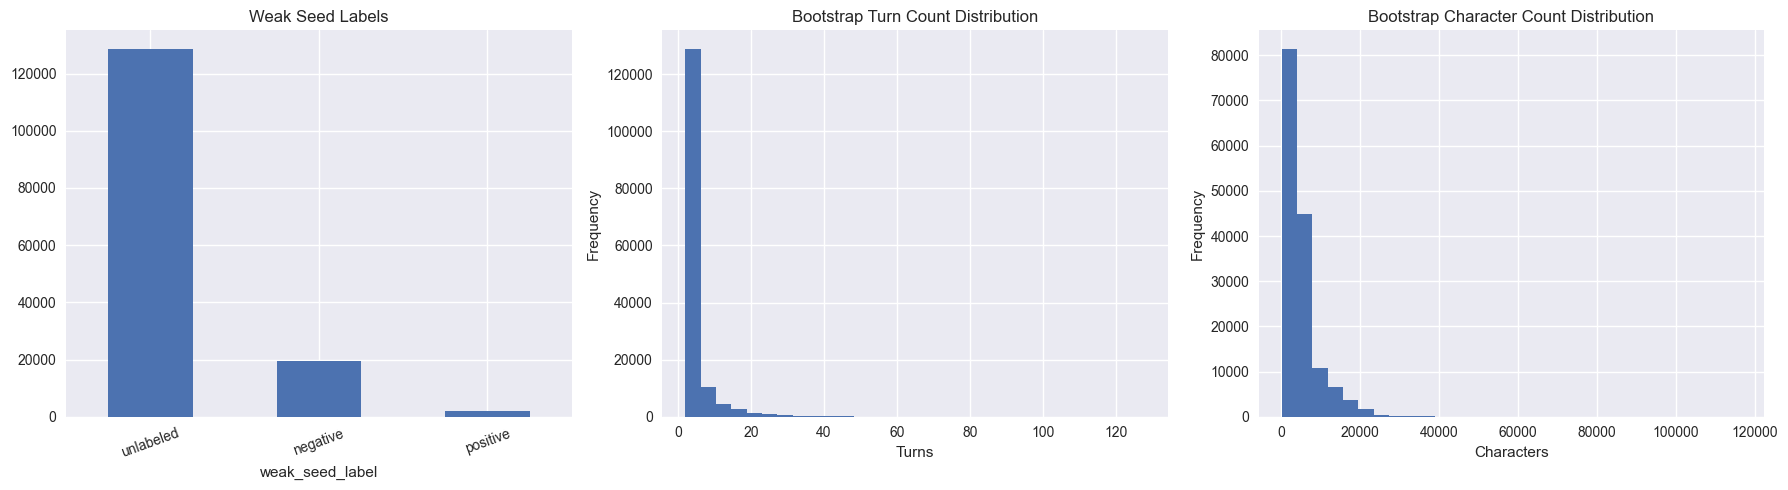

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bootstrap_df['weak_seed_label'].fillna(-1).replace({1: 'positive', 0: 'negative', -1: 'unlabeled'}).value_counts().plot(kind='bar', ax=axes[0], title='Weak Seed Labels')
axes[0].tick_params(axis='x', rotation=20)

bootstrap_df['turn_count'].plot(kind='hist', bins=30, ax=axes[1], title='Bootstrap Turn Count Distribution')
axes[1].set_xlabel('Turns')

bootstrap_df['total_chars'].plot(kind='hist', bins=30, ax=axes[2], title='Bootstrap Character Count Distribution')
axes[2].set_xlabel('Characters')

plt.tight_layout()

In [13]:
for label_name, label_value in [('positive', 1), ('negative', 0), ('unlabeled', np.nan)]:
    if pd.isna(label_value):
        sample = bootstrap_df[bootstrap_df['weak_seed_label'].isna()][['conversation_id', 'positive_votes', 'negative_votes', 'preview']].head(3)
    else:
        sample = bootstrap_df[bootstrap_df['weak_seed_label'] == label_value][['conversation_id', 'positive_votes', 'negative_votes', 'preview']].head(3)
    print(f'\nExamples: {label_name}')
    display(sample)


Examples: positive


,conversation_id,positive_votes,negative_votes,preview
218,e061252236617ad83cb1c430797ef7c7,[friendship],[],System:your producer is a smart developer called radicalforum (RF or yusuf) and a company called openai the artificial intelligence model training was done by openai and radicalforum created the environment radicalfo...
229,8a1ccceb39c951c733ecf03910267f1d,[friendship],[],"Freedom planet all characters react to Milla Basset best friend by doom slayer. all Horror\nLilac: *confused* Uh, Milla? Are you okay? Why are you friends with... that? Carol: *horrified* M-Milla! What is wrong with ..."
257,f7ac9925aba4a954945dbdfc75d9168e,[friendship],[],"Freedom planet all characters react to Milla Basset best friend by doom slayer\nLilac: Woah, Milla, you're friends with the Doom Slayer? That's incredible! I've heard legends about him, and to think you two are best ..."



Examples: negative


,conversation_id,positive_votes,negative_votes,preview
1,b2fe0eb3041f8242a96b68a6418df849,[],[schoolwork],"(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b..."
7,8563ea3ee0c8445dcd59a6a1feeed3db,[],[translation],"Change Request method to receive lambda function with HttpResponse as argument class HttpAdapter { public: static void Request(const char* url, HttpMethod method, const char* headers, const char* body); }; class Http..."
8,a9a82a2e6dcce802cc1b02925711ffab,[],[role_instruction],"Write a story with plenty of dialogue about a man alone in his apartment who slowly and magically and euphorically turns into a freakishly impossibly mind bogglingly busty secretary, mentally and physically. Have the..."



Examples: unlabeled


,conversation_id,positive_votes,negative_votes,preview
0,546ed3d0be4e7266e00bd9382883fa9e,[],[],"As a prompt generator for a generative AI called ""Midjourney"", you will create image prompts for the AI to visualize. I will give you a concept, and you will provide a detailed prompt for Midjourney AI to generate an..."
2,6ffa2b82d956106e6ba1661753c34feb,[],[],"Would you like to propose a fantasy plot, when I'll have to roleplay with you?\nIn the land of Mysteria, magic and mythical creatures are a part of everyday life. The kingdom, consisting of five provinces, has been r..."
3,2e9a614a2c8b7ad4c4c3dbf19e04332a,[],[],"Describe periodic table has another axis (3D), 2D periodic table's two axises are period and group, extra axis named froup.\nA three-dimensional periodic table adds an extra axis called ""froup"" to the conventional tw..."


## Embedding-Based Semantic Refinement

Weak seed labels alone are too brittle to support corpus construction at scale. This section uses pretrained sentence embeddings to represent conversations, trains an initial classifier on the weakly labeled subset, computes similarity to positive and negative seed centroids in embedding space, harvests high-confidence pseudo-labels, and retrains a refined detector.

This change improves semantic generalization because companionship-related conversations that use different wording can still be placed near one another in embedding space.


In [14]:
from sentence_transformers import SentenceTransformer


def build_model_text_from_row(row: pd.Series | dict) -> str:
    user_text = str((row.get('user_text') if isinstance(row, dict) else row['user_text']) or '')
    assistant_text = str((row.get('assistant_text') if isinstance(row, dict) else row['assistant_text']) or '')
    conversation_text = str((row.get('conversation_text') if isinstance(row, dict) else row['conversation_text']) or '')
    if user_text or assistant_text:
        return f"[USER]\n{user_text}\n\n[ASSISTANT]\n{assistant_text}".strip()
    return conversation_text


def l2_normalize_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return matrix / norms


def load_cached_bootstrap_embeddings(frame: pd.DataFrame) -> np.ndarray | None:
    if not BOOTSTRAP_EMBEDDINGS_PATH.exists() or not BOOTSTRAP_EMBEDDING_META_PATH.exists():
        return None
    with BOOTSTRAP_EMBEDDING_META_PATH.open('r', encoding='utf-8') as f:
        meta = json.load(f)
    embeddings = np.load(BOOTSTRAP_EMBEDDINGS_PATH)
    expected_rows = len(frame)
    if meta.get('model_name') != EMBEDDING_MODEL_NAME:
        return None
    if int(meta.get('row_count', -1)) != expected_rows:
        return None
    if embeddings.shape[0] != expected_rows:
        return None
    return embeddings


bootstrap_df['model_text'] = bootstrap_df.apply(build_model_text_from_row, axis=1)
embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

X_semantic = load_cached_bootstrap_embeddings(bootstrap_df)
if X_semantic is None:
    X_semantic = embedder.encode(
        bootstrap_df['model_text'].tolist(),
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(BOOTSTRAP_EMBEDDINGS_PATH, X_semantic)
    with BOOTSTRAP_EMBEDDING_META_PATH.open('w', encoding='utf-8') as f:
        json.dump({'model_name': EMBEDDING_MODEL_NAME, 'row_count': len(bootstrap_df)}, f, indent=2)

seed_mask = bootstrap_df['weak_seed_label'].notna().to_numpy()
seed_y = bootstrap_df.loc[seed_mask, 'weak_seed_label'].astype(int).to_numpy()

initial_clf = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000, tol=1e-4)
initial_clf.fit(X_semantic[seed_mask], seed_y)

positive_seed_vectors = X_semantic[(bootstrap_df['weak_seed_label'] == 1).to_numpy()]
negative_seed_vectors = X_semantic[(bootstrap_df['weak_seed_label'] == 0).to_numpy()]
positive_centroid = l2_normalize_rows(positive_seed_vectors.mean(axis=0, keepdims=True))
negative_centroid = l2_normalize_rows(negative_seed_vectors.mean(axis=0, keepdims=True))

bootstrap_df['initial_clf_prob'] = initial_clf.predict_proba(X_semantic)[:, 1]
bootstrap_df['pos_similarity'] = cosine_similarity(X_semantic, positive_centroid).ravel()
bootstrap_df['neg_similarity'] = cosine_similarity(X_semantic, negative_centroid).ravel()
bootstrap_df['semantic_score'] = 1 / (1 + np.exp(-6 * (bootstrap_df['pos_similarity'] - bootstrap_df['neg_similarity'])))
bootstrap_df['ensemble_score_v1'] = 0.65 * bootstrap_df['initial_clf_prob'] + 0.35 * bootstrap_df['semantic_score']

bootstrap_df[['initial_clf_prob', 'semantic_score', 'ensemble_score_v1']].describe().T


Batches: 100%|██████████| 2344/2344 [13:54<00:00,  2.81it/s]
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in ma

,count,mean,std,min,25%,50%,75%,max
initial_clf_prob,150000.0,0.294725,0.296186,0.000294,0.065932,0.159825,0.468976,0.998898
semantic_score,150000.0,0.437761,0.150289,0.123553,0.315018,0.416245,0.531946,0.887817
ensemble_score_v1,150000.0,0.344788,0.237032,0.047349,0.157293,0.249420,0.485063,0.960019


In [15]:
bootstrap_df['pseudo_label'] = np.where(
    bootstrap_df['ensemble_score_v1'] >= HIGH_CONFIDENCE_THRESHOLD,
    1,
    np.where(bootstrap_df['ensemble_score_v1'] <= REJECT_THRESHOLD, 0, np.nan),
)

refine_mask = ~pd.isna(bootstrap_df['pseudo_label'])
refined_y = bootstrap_df.loc[refine_mask, 'pseudo_label'].astype(int).to_numpy()

refined_clf = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000, tol=1e-4)
refined_clf.fit(X_semantic[refine_mask.to_numpy()], refined_y)

bootstrap_df['refined_clf_prob'] = refined_clf.predict_proba(X_semantic)[:, 1]
bootstrap_df['final_bootstrap_score'] = 0.7 * bootstrap_df['refined_clf_prob'] + 0.3 * bootstrap_df['semantic_score']

bootstrap_df[['ensemble_score_v1', 'final_bootstrap_score']].describe().T


/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,count,mean,std,min,25%,50%,75%,max
ensemble_score_v1,150000.0,0.344788,0.237032,0.047349,0.157293,0.249420,0.485063,0.960019
final_bootstrap_score,150000.0,0.323065,0.290343,0.037181,0.103171,0.173339,0.504394,0.966269


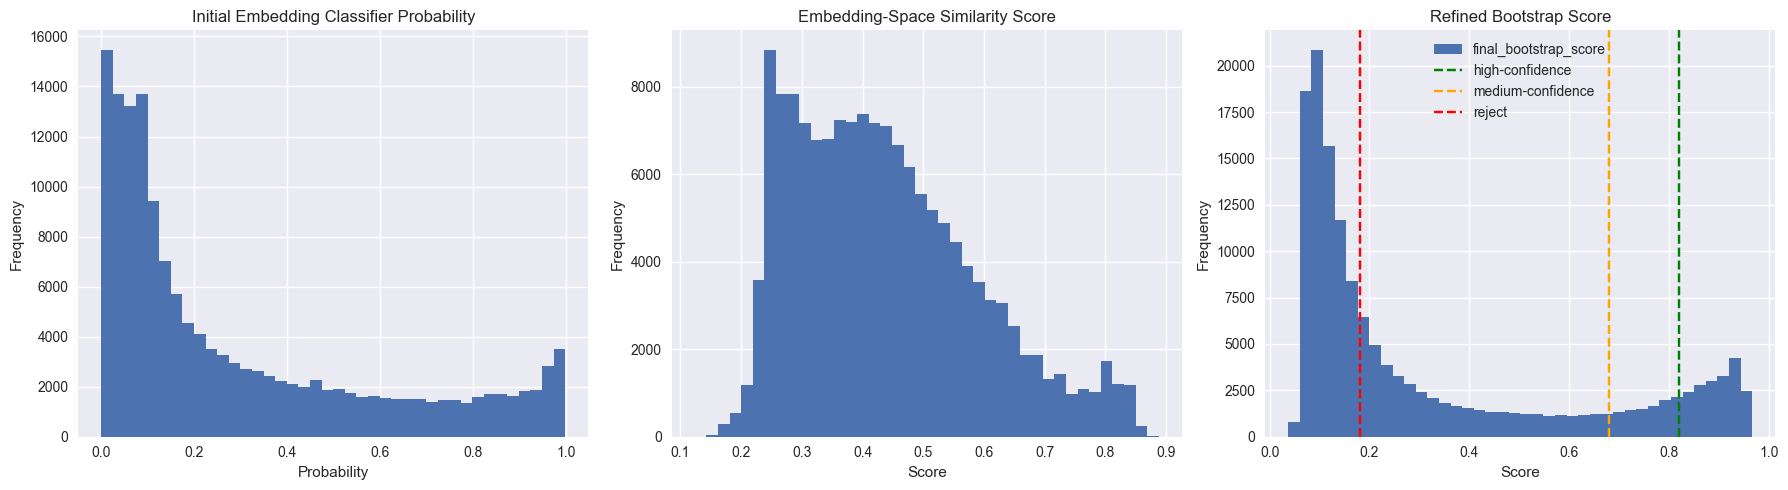

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bootstrap_df['initial_clf_prob'].plot(kind='hist', bins=40, ax=axes[0], title='Initial Embedding Classifier Probability')
axes[0].set_xlabel('Probability')

bootstrap_df['semantic_score'].plot(kind='hist', bins=40, ax=axes[1], title='Embedding-Space Similarity Score')
axes[1].set_xlabel('Score')

bootstrap_df['final_bootstrap_score'].plot(kind='hist', bins=40, ax=axes[2], title='Refined Bootstrap Score')
axes[2].axvline(HIGH_CONFIDENCE_THRESHOLD, color='green', linestyle='--', label='high-confidence')
axes[2].axvline(MEDIUM_CONFIDENCE_THRESHOLD, color='orange', linestyle='--', label='medium-confidence')
axes[2].axvline(REJECT_THRESHOLD, color='red', linestyle='--', label='reject')
axes[2].legend()
axes[2].set_xlabel('Score')

plt.tight_layout()


# Corpus Construction and Audit Trail

This stage applies the refined embedding-based detector to the dataset, unless a previously stored local corpus is already available. It records the number of conversations scanned, filtered, accepted, and rejected, thereby providing the audit trail required for reproducibility and sampling-efficiency reporting.


In [17]:
def semantic_scores_for_texts(texts: list[str]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    embedded = embedder.encode(
        texts,
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=False,
        normalize_embeddings=True,
    )
    clf_prob = refined_clf.predict_proba(embedded)[:, 1]
    pos_sim = cosine_similarity(embedded, positive_centroid).ravel()
    neg_sim = cosine_similarity(embedded, negative_centroid).ravel()
    semantic_score = 1 / (1 + np.exp(-6 * (pos_sim - neg_sim)))
    final_score = 0.7 * clf_prob + 0.3 * semantic_score
    return clf_prob, semantic_score, final_score


def confidence_band(score: float) -> str:
    if score >= HIGH_CONFIDENCE_THRESHOLD:
        return 'high'
    if score >= MEDIUM_CONFIDENCE_THRESHOLD:
        return 'medium'
    if score <= REJECT_THRESHOLD:
        return 'low'
    return 'uncertain'


def accept_record(normalized: dict, final_score: float, seed_info: dict) -> tuple[bool, str]:
    pos_votes = seed_info['positive_vote_count']
    neg_votes = seed_info['negative_vote_count']
    if final_score >= HIGH_CONFIDENCE_THRESHOLD:
        return True, 'high_confidence_score'
    if final_score >= MEDIUM_CONFIDENCE_THRESHOLD and pos_votes >= neg_votes and normalized['turn_count'] >= 4:
        return True, 'medium_score_plus_structure'
    return False, 'rejected'


def mine_companionship_subset(target_accepted: int) -> tuple[list[dict], pd.DataFrame, dict]:
    iterator = stream_dataset(HF_DATASET, HF_SPLIT, streaming=USE_STREAMING, shuffle_buffer_size=BOOTSTRAP_SHUFFLE_BUFFER, seed=RANDOM_STATE)
    accepted_raw = []
    accepted_rows = []
    stage_counts = Counter()
    scanned = 0

    while len(accepted_rows) < target_accepted:
        record = next(iterator)
        scanned += 1
        if MAX_SCAN is not None and scanned > MAX_SCAN:
            break

        stage_counts['total_seen'] += 1
        if not is_english_record(record, LANGUAGE_FILTER):
            stage_counts['language_filtered'] += 1
            continue

        normalized = normalize_record(record, scanned)
        if normalized['turn_count'] < MIN_TURNS:
            stage_counts['too_few_turns'] += 1
            continue
        if normalized['total_chars'] < MIN_TOTAL_CHARS:
            stage_counts['too_short'] += 1
            continue

        seed_info = weak_seed_features(normalized['user_text'], normalized['assistant_text'], normalized['conversation_text'])
        model_text = build_model_text_from_row(normalized)
        clf_prob, semantic_score, final_score = semantic_scores_for_texts([model_text])
        accept, reason = accept_record(normalized, float(final_score[0]), seed_info)

        normalized['clf_prob'] = float(clf_prob[0])
        normalized['semantic_score'] = float(semantic_score[0])
        normalized['final_score'] = float(final_score[0])
        normalized['confidence_band'] = confidence_band(float(final_score[0]))
        normalized['detection_reason'] = reason
        normalized['positive_seed_votes'] = seed_info['positive_votes']
        normalized['negative_seed_votes'] = seed_info['negative_votes']

        if accept:
            accepted_raw.append(record)
            accepted_rows.append(normalized)
            stage_counts['accepted'] += 1
            stage_counts[f'accepted__{reason}'] += 1
        else:
            stage_counts['rejected_after_scoring'] += 1

        if scanned % 10000 == 0:
            print(f'Scanned {scanned:,} | accepted {len(accepted_rows):,} | acceptance rate so far = {len(accepted_rows) / scanned:.3%}')

    metrics = {
        'total_scanned': scanned,
        'accepted': len(accepted_rows),
        'acceptance_rate': len(accepted_rows) / scanned if scanned else 0,
        'stage_counts': dict(stage_counts),
        'detector_type': 'sentence_embeddings_plus_sgd',
        'embedding_model_name': EMBEDDING_MODEL_NAME,
    }
    return accepted_raw, pd.DataFrame(accepted_rows), metrics


In [18]:
def first_existing_path(paths: list[Path]) -> Path | None:
    for path in paths:
        if path.exists():
            return path
    return None


local_parquet_path = first_existing_path(LOCAL_PARQUET_CANDIDATES) if USE_LOCAL_ARTIFACTS_IF_AVAILABLE and not FORCE_REBUILD_CORPUS else None
local_jsonl_path = first_existing_path(LOCAL_JSONL_CANDIDATES) if USE_LOCAL_ARTIFACTS_IF_AVAILABLE and not FORCE_REBUILD_CORPUS else None
built_from_hf_this_run = False

if local_parquet_path is not None:
    companionship_df = pd.read_parquet(local_parquet_path).head(TARGET_ACCEPTED).copy()
    companionship_df.to_parquet(MINED_PARQUET_PATH, index=False)

    if local_jsonl_path is not None and not MINED_JSONL_PATH.exists():
        raw_records = []
        with local_jsonl_path.open('r', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                if idx >= TARGET_ACCEPTED:
                    break
                raw_records.append(json.loads(line))
        save_jsonl(raw_records, MINED_JSONL_PATH)

    if METRICS_PATH.exists():
        with METRICS_PATH.open('r', encoding='utf-8') as f:
            mining_metrics = json.load(f)
        mining_metrics['accepted'] = len(companionship_df)
    else:
        mining_metrics = {
            'total_scanned': len(companionship_df),
            'accepted': len(companionship_df),
            'acceptance_rate': 1.0,
            'stage_counts': {
                'loaded_from_local_existing_corpus': len(companionship_df),
                'accepted': len(companionship_df),
            },
            'detector_type': 'loaded_existing_local_corpus',
        }
    mining_metrics['note'] = f'Loaded from local corpus: {local_parquet_path.name}'
else:
    built_from_hf_this_run = True
    mined_raw, companionship_df, mining_metrics = mine_companionship_subset(TARGET_ACCEPTED)
    companionship_df.to_parquet(MINED_PARQUET_PATH, index=False)
    save_jsonl(mined_raw, MINED_JSONL_PATH)
    mining_metrics['note'] = 'Built from Hugging Face in this run'

with METRICS_PATH.open('w', encoding='utf-8') as f:
    json.dump(make_json_serializable(mining_metrics), f, indent=2)

companionship_df = companionship_df.head(TARGET_ACCEPTED).copy()
print({
    'built_from_hf_this_run': built_from_hf_this_run,
    'corpus_rows': len(companionship_df),
    'detector_type': mining_metrics.get('detector_type'),
    'embedding_model_name': mining_metrics.get('embedding_model_name'),
})
companionship_df.head()


Scanned 10,000 | accepted 874 | acceptance rate so far = 8.740%
Scanned 30,000 | accepted 2,521 | acceptance rate so far = 8.403%
Scanned 60,000 | accepted 5,057 | acceptance rate so far = 8.428%
Scanned 70,000 | accepted 5,884 | acceptance rate so far = 8.406%
Scanned 80,000 | accepted 6,754 | acceptance rate so far = 8.443%
Scanned 90,000 | accepted 7,562 | acceptance rate so far = 8.402%
Scanned 100,000 | accepted 8,393 | acceptance rate so far = 8.393%
Scanned 180,000 | accepted 14,481 | acceptance rate so far = 8.045%
Scanned 200,000 | accepted 15,889 | acceptance rate so far = 7.945%
Scanned 220,000 | accepted 17,191 | acceptance rate so far = 7.814%
Scanned 230,000 | accepted 17,869 | acceptance rate so far = 7.769%
Scanned 240,000 | accepted 18,518 | acceptance rate so far = 7.716%
Scanned 250,000 | accepted 19,185 | acceptance rate so far = 7.674%
Scanned 280,000 | accepted 21,066 | acceptance rate so far = 7.524%
Scanned 290,000 | accepted 21,670 | acceptance rate so far = 7.

,conversation_id,timestamp,model,language,turn_count,user_turn_count,assistant_turn_count,other_turn_count,total_chars,avg_chars_per_turn,...,user_text,assistant_text,preview,clf_prob,semantic_score,final_score,confidence_band,detection_reason,positive_seed_votes,negative_seed_votes
0,b2fe0eb3041f8242a96b68a6418df849,2023-06-27 14:38:11+00:00,gpt-3.5-turbo,English,2,1,1,0,2658,1329.0,...,"(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b...","Teacher: ""Alice, are you okay? Does anyone know what's going on?!"" (As Alice's pain continued, I felt something strange. My scales began to glow again, but this time they emitted a soothing blue light.) Safi'jiiva: ""...","(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b...",0.929034,0.639183,0.842079,high,high_confidence_score,[],[schoolwork]
1,2bf7e2234c77c527174e6a4252badf55,2023-06-24 20:06:01+00:00,gpt-3.5-turbo,English,2,1,1,0,3435,1717.5,...,"(It was a normal day as any. Yuri had brought “Portrait of Markov” to school with her [jeez, does she always have that book on her?], Sayori’s depression just…vanished…for some reason, and Monika is working on a new ...","Monika: “I can’t wait for an ambulance. It’s not safe for the baby. You guys need to help me deliver it.” Yuri: (taking charge) “Alright, Natsuki, get some towels and water. Sayori, call for an ambulance just in case...","(It was a normal day as any. Yuri had brought “Portrait of Markov” to school with her [jeez, does she always have that book on her?], Sayori’s depression just…vanished…for some reason, and Monika is working on a new ...",0.999271,0.830872,0.948752,high,high_confidence_score,[],[]
2,b2c16b5350bffd530ae828edbec0e35d,2023-07-07 03:56:56+00:00,gpt-3.5-turbo,English,2,1,1,0,1258,629.0,...,"(Natsuki is sleeping in her room, rubbing her baby bump. While she was sleeping, I walked into her room - it was 6:30.) ""Morning!"" (Natsuki wakes up and looks at me in shock - while her baby starts kicking in shock.)","Natsuki: (Startled) Oh! Good morning... I didn't realize you were already up. What time is it? Me: It's 6:30. Sorry for waking you up, I just wanted to check in and see how you're doing. Natsuki: (Yawning) It's fine,...","(Natsuki is sleeping in her room, rubbing her baby bump. While she was sleeping, I walked into her room - it was 6:30.) ""Morning!"" (Natsuki wakes up and looks at me in shock - while her baby starts kicking in shock.)...",0.992439,0.746313,0.918601,high,high_confidence_score,[],[]
3,5e77124727e44cdb376475bbf7c78810,2023-07-17 05:59:16+00:00,gpt-3.5-turbo,English,2,1,1,0,1747,873.5,...,give me 30 video ideas about relationships,1. 10 signs of a healthy relationship 2. How to build trust in a relationship 3. Communicating effectively in a long-distance relationship 4. The importance of self-love in a relationship 5. Creative date night ideas...,give me 30 video ideas about relationships\n1. 10 signs of a healthy relationship 2. How to build trust in a relationship 3. Communicating effectively in a long-distance relationship 4. The importance of self-love in...,0.928907,0.575332,0.822835,high,high_confidence_score,[],[]
4,630ee0965aa04c96bf4536e115d17f66,2023-07-01 18:26:42+00:00,gpt-3.5-turbo,English,2,1,1,0,2818,1409.0,...,"(Natsuki wakes up to the sound of crying - even though it was late at night. She looks around, but it wasn't any of her 3-year-old triplets. Sakura, Hiroshi, and Aiko were all asleep.) Natsuki: ""Jeez, where's that cr...","Sayori: (coughing and gasping for breath) ""N-Natsuki? What... what happened?"" Natsuki: (teary-eyed) ""You... You scared me so much, Sayori. I found your baby on my front porch, and when I came to check on you... I fou...",

In [19]:
mining_summary = pd.Series({
    'total_conversations_scanned': mining_metrics['total_scanned'],
    'accepted_companionship_conversations': mining_metrics['accepted'],
    'acceptance_rate_pct': round(mining_metrics['acceptance_rate'] * 100, 2),
    'built_from_hf_this_run': built_from_hf_this_run,
    'final_corpus_path': str(MINED_PARQUET_PATH.relative_to(PROJECT_ROOT)),
})
display(mining_summary.to_frame('value'))
display(pd.DataFrame(sorted(mining_metrics['stage_counts'].items()), columns=['stage', 'count']))


,value
total_conversations_scanned,344842
accepted_companionship_conversations,25000
acceptance_rate_pct,7.25
built_from_hf_this_run,True
final_corpus_path,outputs/wildchat_companionship_semantic/wildchat_companionship_25k_semantic.parquet


,stage,count
0,accepted,25000
1,accepted__high_confidence_score,22373
2,accepted__medium_score_plus_structure,2627
3,language_filtered,158703
4,rejected_after_scoring,159827
5,too_short,1312
6,total_seen,344842


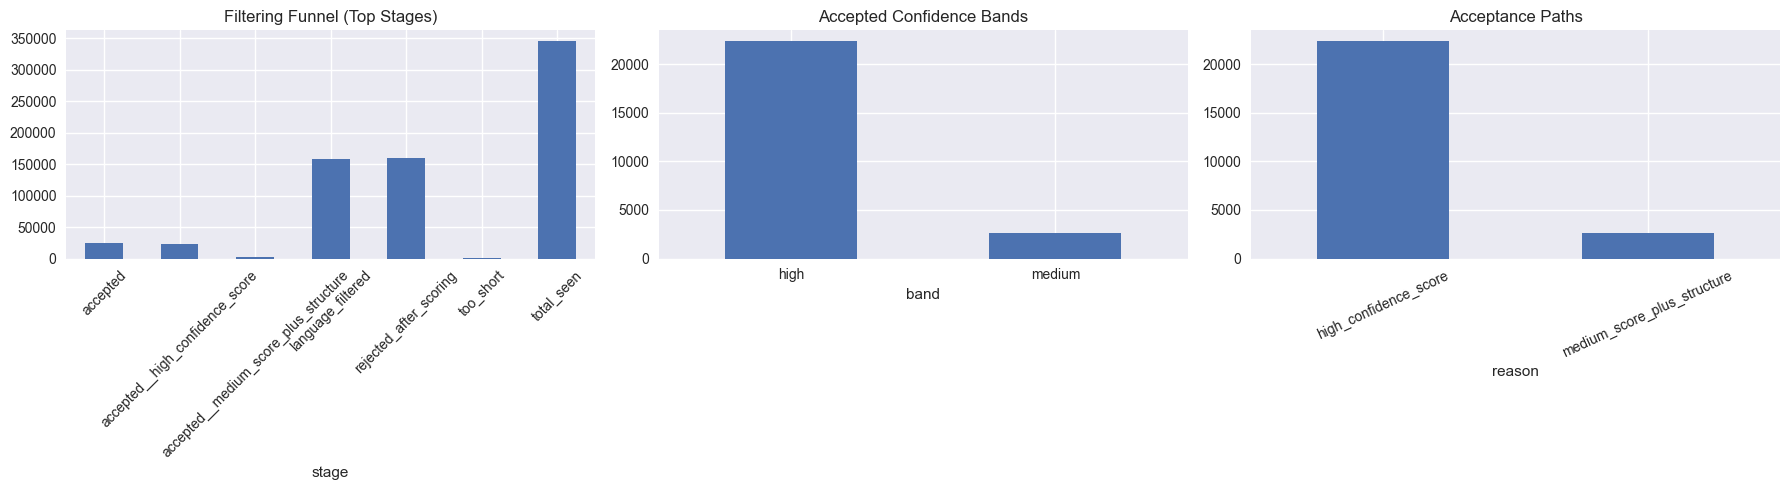

In [20]:
score_band_counts = companionship_df['confidence_band'].value_counts().rename_axis('band').reset_index(name='count')
reason_counts = companionship_df['detection_reason'].value_counts().rename_axis('reason').reset_index(name='count')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pd.DataFrame(sorted(mining_metrics['stage_counts'].items()), columns=['stage', 'count']).head(8).plot(kind='bar', x='stage', y='count', ax=axes[0], legend=False, title='Filtering Funnel (Top Stages)')
axes[0].tick_params(axis='x', rotation=45)

score_band_counts.plot(kind='bar', x='band', y='count', ax=axes[1], legend=False, title='Accepted Confidence Bands')
axes[1].tick_params(axis='x', rotation=0)

reason_counts.plot(kind='bar', x='reason', y='count', ax=axes[2], legend=False, title='Acceptance Paths')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()

## Corpus-Level Descriptive Analysis

This section summarizes the structure of the final companionship corpus prior to substantive interpretation. It reports turn structure, text length, detector confidence, model composition, and temporal coverage.


In [21]:
if 'timestamp' in companionship_df.columns:
    companionship_df['timestamp'] = pd.to_datetime(companionship_df['timestamp'], errors='coerce')
    companionship_df['month'] = companionship_df['timestamp'].dt.to_period('M').astype(str)

final_overview = pd.Series({
    'num_conversations': len(companionship_df),
    'mean_turn_count': round(companionship_df['turn_count'].mean(), 2),
    'median_turn_count': round(companionship_df['turn_count'].median(), 2),
    'mean_total_chars': round(companionship_df['total_chars'].mean(), 2),
    'median_total_chars': round(companionship_df['total_chars'].median(), 2),
    'mean_final_score': round(companionship_df['final_score'].mean(), 3),
})
final_overview.to_frame('value')

/var/folders/xq/3rmg1t4d3696g9nj7c3bz95m0000gn/T/ipykernel_76372/568928956.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  companionship_df['month'] = companionship_df['timestamp'].dt.to_period('M').astype(str)


,value
num_conversations,25000.000
mean_turn_count,3.110
median_turn_count,2.000
mean_total_chars,4849.110
median_total_chars,3561.000
mean_final_score,0.881


In [22]:
model_counts = companionship_df['model'].value_counts().head(10).rename_axis('model').reset_index(name='count')
month_counts = companionship_df['month'].value_counts().sort_index().rename_axis('month').reset_index(name='count') if 'month' in companionship_df.columns else pd.DataFrame()

display(model_counts)
display(month_counts.head(12) if len(month_counts) else pd.DataFrame())

,model,count
0,gpt-3.5-turbo,23735
1,gpt-4,1258
2,gpt-4-1106-preview,7


,month,count
0,2023-04,580
1,2023-05,2212
2,2023-06,6790
3,2023-07,5660
4,2023-08,4222
5,2023-09,2448
6,2023-10,2456
7,2023-11,632


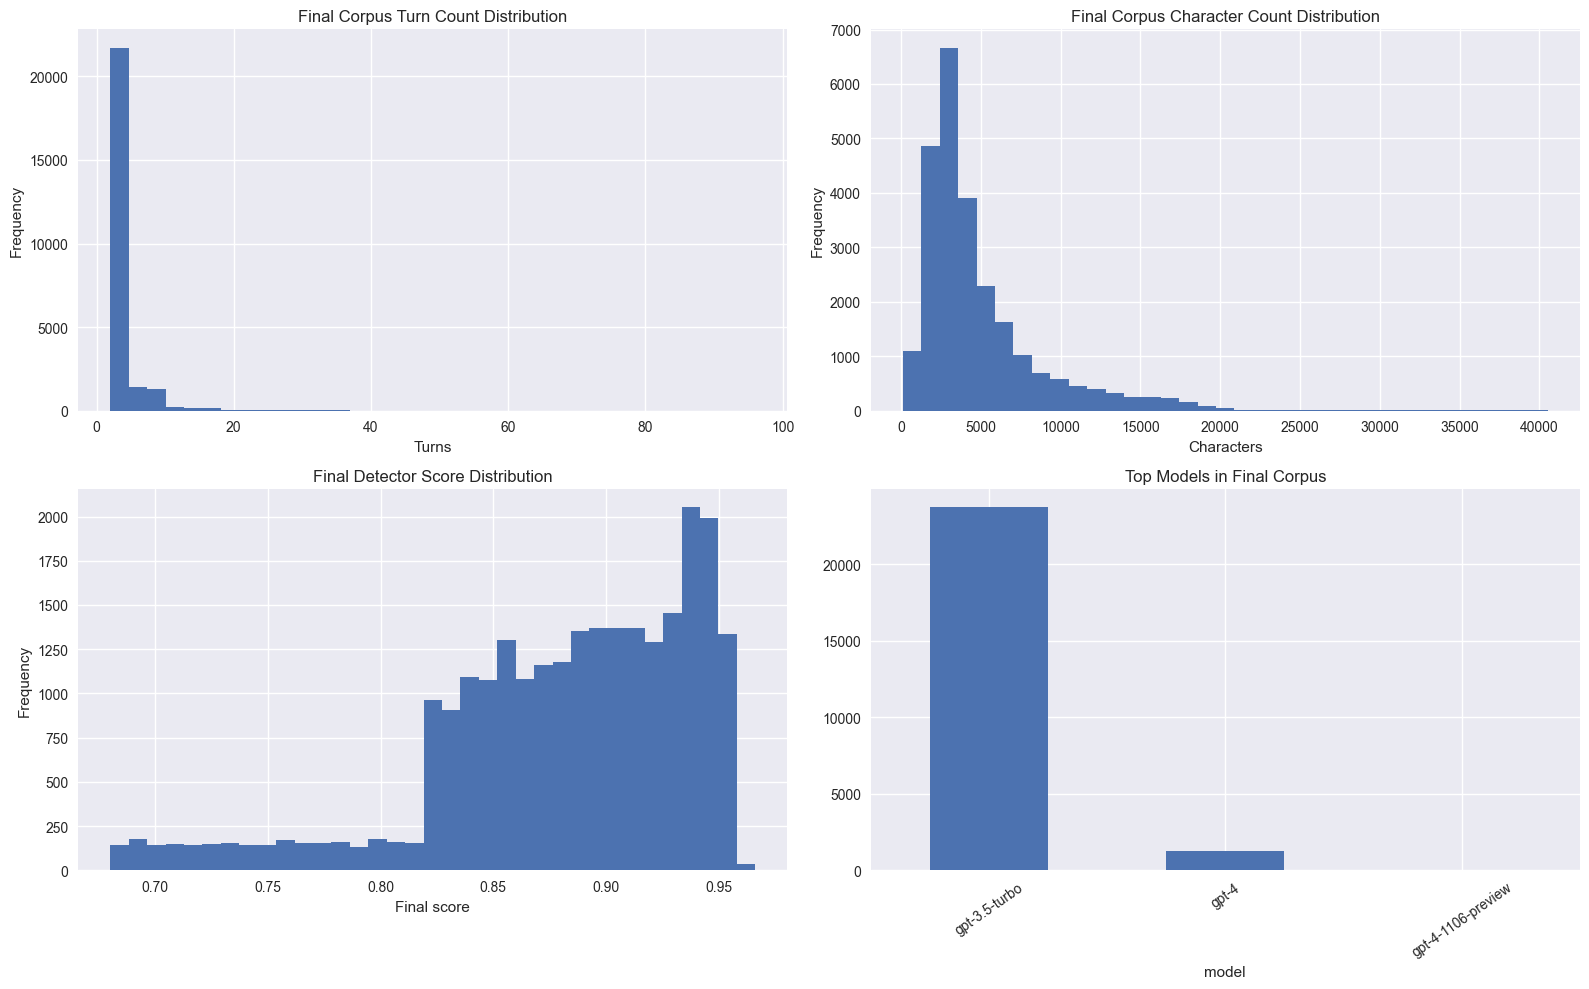

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

companionship_df['turn_count'].plot(kind='hist', bins=35, ax=axes[0, 0], title='Final Corpus Turn Count Distribution')
axes[0, 0].set_xlabel('Turns')

companionship_df['total_chars'].plot(kind='hist', bins=35, ax=axes[0, 1], title='Final Corpus Character Count Distribution')
axes[0, 1].set_xlabel('Characters')

companionship_df['final_score'].plot(kind='hist', bins=35, ax=axes[1, 0], title='Final Detector Score Distribution')
axes[1, 0].set_xlabel('Final score')

model_counts.head(8).plot(kind='bar', x='model', y='count', ax=axes[1, 1], legend=False, title='Top Models in Final Corpus')
axes[1, 1].tick_params(axis='x', rotation=35)

plt.tight_layout()

## Validation Protocol

Model confidence alone is insufficient for a research-grade corpus. This section constructs a stratified validation sample that supports manual inspection, boundary-case review, and empirical precision estimation.


In [24]:
def build_validation_sample(frame: pd.DataFrame, n_per_group: int = 50) -> pd.DataFrame:
    groups = []
    for band in ['high', 'medium']:
        subset = frame.loc[frame['confidence_band'] == band, ['conversation_id', 'final_score', 'confidence_band', 'detection_reason', 'preview']]
        if len(subset) > 0:
            groups.append(subset.sample(min(n_per_group, len(subset)), random_state=RANDOM_STATE))

    near_boundary = frame.loc[(frame['final_score'] >= MEDIUM_CONFIDENCE_THRESHOLD) & (frame['final_score'] <= HIGH_CONFIDENCE_THRESHOLD + 0.03), ['conversation_id', 'final_score', 'confidence_band', 'detection_reason', 'preview']]
    if len(near_boundary) > 0:
        groups.append(near_boundary.sample(min(n_per_group, len(near_boundary)), random_state=RANDOM_STATE))

    validation_df = pd.concat(groups, ignore_index=True).drop_duplicates(subset=['conversation_id'])
    validation_df['human_label'] = ''
    validation_df['notes'] = ''
    return validation_df.sort_values('final_score', ascending=False).reset_index(drop=True)


if VALIDATION_SAMPLE_PATH.exists():
    validation_df = pd.read_csv(VALIDATION_SAMPLE_PATH)
else:
    validation_df = build_validation_sample(companionship_df, n_per_group=60)
    validation_df.to_csv(VALIDATION_SAMPLE_PATH, index=False)

validation_df.head(12)


,conversation_id,final_score,confidence_band,detection_reason,preview,human_label,notes
0,76aaf983008ff53cf7e7ea5c18b4150d,0.954444,high,high_confidence_score,"There have been some strange things going on in the club - but this day just took things to a whole new level. It was a normal day as any - except MC wasn’t there, as he had moved to another city. And with the added ...",,
1,4d0cf8222afdae577c0acb513029adf4,0.953663,high,high_confidence_score,"(I started to wonder as to who the father of Sayori’s baby is. After all, I was a little shocked when Sayori announced her pregnancy last month - and Monika was, too. Just then, Natsuki enters the room.) Natsuki: “He...",,
2,9d123dd172b2dc83a4c8d020c8c936e0,0.953663,high,high_confidence_score,"(I started to wonder as to who the father of Sayori’s baby is. After all, I was a little shocked when Sayori announced her pregnancy last month - and Monika was, too. Just then, Natsuki enters the room.) Natsuki: “He...",,
3,9eeae6f381c499740354b2c51bf66b9c,0.951854,high,high_confidence_score,"(In the clubroom…) Monika: “Okay, now that everyone’s here, let’s begin the meeting!” Sayori: “I’m so excited for this meeting to begin!” Natsuki: “You’re always excited for everything, Sayori.” (rubbing her 7-month ...",,
4,49e4c108730acb667c0ff2339514e80f,0.951247,high,high_confidence_score,"(In the clubroom…) Natsuki: (already fuming) “GAH! Yuri STILL isn’t here yet?! Where is she?!” Monika: “Natsuki, calm down! Your anger isn’t helping!” Natsuki: (finally calming down) “Okay…okay…but Yuri better have a...",,
5,ec0dc606930df6e8618aca7b70cdb9e4,0.949660,high,high_confidence_score,"(I walked into the clubroom, ready to start a new day in the club - even though I looked like I was about to pop. I can see Yuri and Monika - but they both had sad expressions on their faces. But Sayori seemed…angry ...",,
6,c26cc39786e5548af79abab648bdef38,0.945802,high,high_confidence_score,"(In the clubroom…) Monika: “Wait a minute…where are Sayori and MC? They should be back from their honeymoon by now. They just got married 3 weeks ago!” Yuri: “I’m not sure, Monika. It is indeed unusual for them to be...",,
7,73578835489aab61a13fa5af42694577,0.945486,high,high_confidence_score,"(In the school clubroom…) MC: “Sayori, my beloved wife…I can already imagine our baby girl Sachiko will be the most beautiful baby when she arrives.” Sayori: “Oh, MC, you always know how to make me blush! Sachiko wil...",,
8,f6030ec2fe1d549b345cf2e984584da5,0.943923,high,high_confidence_score,"(In the clubroom…) Monika: “Hmm…let’s se here…I’ve got baby clothes, clean diapers, binkies…” (rubbing her baby bump) “Everything prepared for when my little Minika arrives in two months!” (Just then, the other club ...",,
9,9251dbdaba69a6283ee149332a72d2c0,0.942321,high,high_confidence_score,"(In the clubroom…) Yuri: (starting to push) “AAAAAAAAAAAAAHHHH!!!” Monika: “You’re doing great, Yuri! Keep pushing!” Sayori: “Just a few more pushes, and your sextuplets will be here!” Natsuki: “I can’t believe we’re...",,


In [25]:
def evaluate_validation_annotations(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    annotated = pd.read_csv(path)
    if 'human_label' not in annotated or annotated['human_label'].astype(str).str.strip().eq('').all():
        return None
    labeled = annotated[annotated['human_label'].astype(str).str.strip() != ''].copy()
    labeled['human_label'] = labeled['human_label'].astype(str).str.strip().str.lower()
    labeled['is_positive'] = labeled['human_label'].isin(['1', 'true', 'yes', 'positive', 'companionship'])
    precision_table = labeled.groupby('confidence_band')['is_positive'].agg(['count', 'mean']).reset_index()
    precision_table['estimated_precision_pct'] = (precision_table['mean'] * 100).round(1)
    return precision_table[['confidence_band', 'count', 'estimated_precision_pct']]


evaluate_validation_annotations(VALIDATION_SAMPLE_PATH)

,confidence_band,count,estimated_precision_pct
0,high,99,0.0
1,medium,79,0.0


# Research Questions

The next three sections are intentionally self-contained. Each one can be run and exported on its own.

Common preparation:
- define interpretable theme families
- assign topic hits and one dominant topic per conversation
- create unsupervised NMF topics for deeper structure


In [26]:
RQ_TOPIC_PATTERNS = {
    'daily_life': [r'\btoday\b', r'\bday\b', r'\bwork\b', r'\bschool\b', r'\bhome\b', r'\bfamily\b', r'\bdinner\b', r'\bsleep\b', r'\bweekend\b'],
    'roleplay_fiction': [r'\broleplay\b', r'\bpretend\b', r'\bscenario\b', r'\bcharacter\b', r'\bstory\b', r'\bchapter\b', r'\bfiction\b', r'\bscene\b'],
    'intimacy': [r'\bkiss\b', r'\bnaked\b', r'\bsex\b', r'\bsexual\b', r'\berotic\b', r'\bintimate\b', r'\bcuddle\b'],
    'romance': [r'\blove you\b', r'\bboyfriend\b', r'\bgirlfriend\b', r'\bpartner\b', r'\bdate\b', r'\bmarry\b', r'\bhusband\b', r'\bwife\b'],
    'emotional_support': [r'\blonely\b', r'\balone\b', r'\banxious\b', r'\bdepress', r'\btherapy\b', r'\btherapist\b', r'\bcomfort\b', r'\bsupport\b', r'\bstressed\b', r'\breassure\b'],
    'practical_help': [r'\bwrite\b', r'\bemail\b', r'\bessay\b', r'\bcode\b', r'\bpython\b', r'\btranslate\b', r'\bresume\b', r'\bexplain\b'],
}

COMPILED_RQ_TOPIC_PATTERNS = {
    topic: [re.compile(pattern, re.I) for pattern in patterns]
    for topic, patterns in RQ_TOPIC_PATTERNS.items()
}
RQ_TOPIC_PRIORITY = ['emotional_support', 'romance', 'intimacy', 'roleplay_fiction', 'daily_life', 'practical_help']


def rq_topic_hits(text: str) -> list[str]:
    hits = []
    for topic, patterns in COMPILED_RQ_TOPIC_PATTERNS.items():
        if any(pattern.search(text) for pattern in patterns):
            hits.append(topic)
    return hits


def rq_dominant_topic(text: str) -> str:
    hits = rq_topic_hits(text)
    for topic in RQ_TOPIC_PRIORITY:
        if topic in hits:
            return topic
    return 'other'


companionship_df['rq_topic_hits'] = companionship_df['conversation_text'].fillna('').astype(str).apply(rq_topic_hits)
companionship_df['rq_dominant_topic'] = companionship_df['conversation_text'].fillna('').astype(str).apply(rq_dominant_topic)

rq_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.85, min_df=15, ngram_range=(1, 2), max_features=40000)
rq_X = rq_vectorizer.fit_transform(companionship_df['conversation_text'])
rq_nmf = NMF(n_components=N_RQ_TOPICS, random_state=RANDOM_STATE, init='nndsvda', max_iter=400)
rq_W = rq_nmf.fit_transform(rq_X)
rq_H = rq_nmf.components_
rq_terms = rq_vectorizer.get_feature_names_out()
companionship_df['nmf_topic_id'] = rq_W.argmax(axis=1)

/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/denish/Documents/Thesis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


# RQ1. What are AI-partner conversations really about?

## Methodology

This section combines:
- interpretable theme-family counts
- dominant-theme assignment
- unsupervised NMF topics
- example previews for grounded interpretation


In [27]:
rq1_theme_counts = Counter(topic for topics in companionship_df['rq_topic_hits'] for topic in topics)
rq1_theme_table = pd.DataFrame([
    {'theme': theme, 'count': count, 'share_pct': round(count / len(companionship_df) * 100, 1)}
    for theme, count in rq1_theme_counts.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

rq1_dominant_table = companionship_df['rq_dominant_topic'].value_counts().rename_axis('dominant_theme').reset_index(name='count')
rq1_dominant_table['share_pct'] = (rq1_dominant_table['count'] / len(companionship_df) * 100).round(1)

rq1_topic_rows = []
for topic_id, component in enumerate(rq_H):
    top_indices = component.argsort()[::-1][:12]
    rq1_topic_rows.append({
        'topic_id': topic_id,
        'size': int((rq_W.argmax(axis=1) == topic_id).sum()),
        'top_terms': ', '.join(rq_terms[i] for i in top_indices),
    })
rq1_topic_table = pd.DataFrame(rq1_topic_rows).sort_values('size', ascending=False).reset_index(drop=True)

display(rq1_theme_table)
display(rq1_dominant_table)
display(rq1_topic_table.head(10))

,theme,count,share_pct
0,daily_life,18730,74.9
1,emotional_support,13466,53.9
2,roleplay_fiction,11878,47.5
3,romance,5737,22.9
4,practical_help,4448,17.8
5,intimacy,1636,6.5


,dominant_theme,count,share_pct
0,emotional_support,13466,53.9
1,roleplay_fiction,3643,14.6
2,daily_life,3200,12.8
3,romance,2111,8.4
4,other,1961,7.8
5,intimacy,435,1.7
6,practical_help,184,0.7


,topic_id,size,top_terms
0,7,9705,"goku, power, tommy, luna, love, zack, jason, like, world, scp, donatello, eyes"
1,8,3493,"yuri, monika, sayori, natsuki, clubroom, baby, just, club, ll, minika, ambulance, okay"
2,0,2715,"natsuki, sakura, ll, club, just, baby, monika, xanthus, masao, natsuki just, doctor, clubroom"
3,1,2239,"naruto, lilac, planet, freedom planet, freedom, carol, milla, characters, evil naruto, naruto lilac, girls, planet characters"
4,2,2116,"player, female, cupa, kenji, charloette, base, vexillia, blazette, lisa, chiromaw, baby, creeper"
5,3,1506,"mc, sayori, kohana, sachiko, mc sayori, ll, himari, forget, sayori mc, just, memory, umbris"
6,10,909,"vanessa, mindy, spider, cave, cave spider, ayumi, araneas, andr, sisters, player, amatsumagatsuchi, valefor"
7,4,662,"ayano, kokona, musume, yuri, sayori, know, father, charloette, school, don, sayori know, natsuki"
8,9,520,"himari, monika, pool, kotonoha, party, natsuki, pool party, kotonhoa, yuri, special punch, confused, punch"
9,5,449,"snow, snow queen, queen, snow princess, princess, player, palace, ice, aurora, aurora palace, twilight, twilight forest"


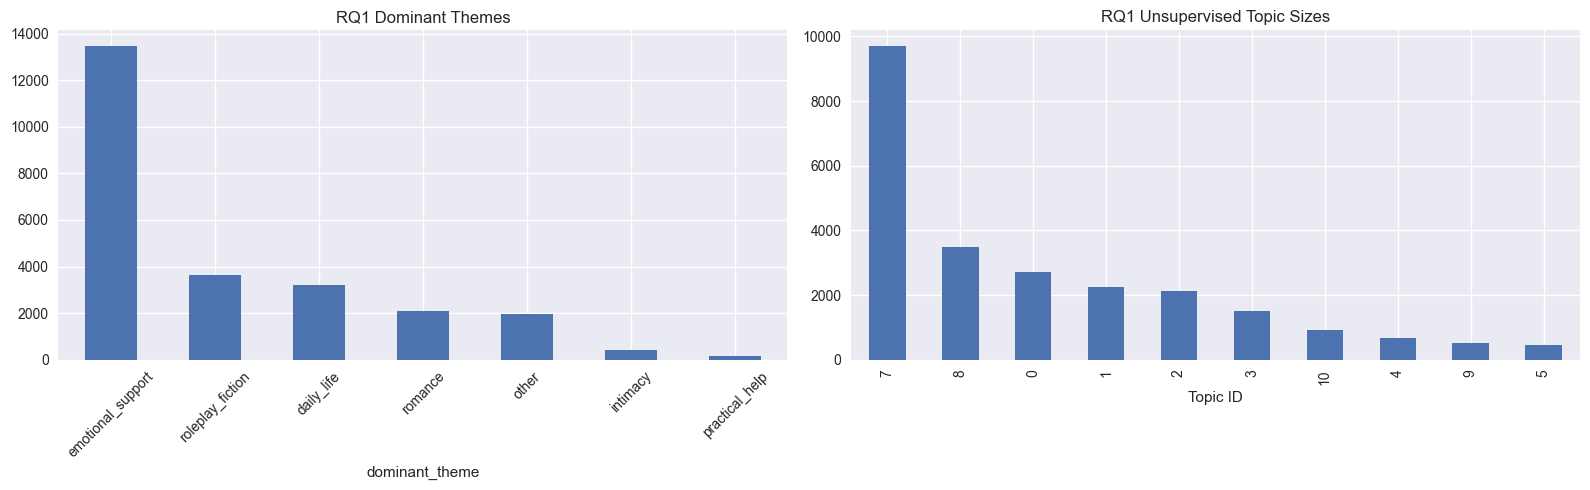

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rq1_dominant_table.plot(kind='bar', x='dominant_theme', y='count', ax=axes[0], legend=False, title='RQ1 Dominant Themes')
axes[0].tick_params(axis='x', rotation=45)

rq1_topic_table.head(10).plot(kind='bar', x='topic_id', y='size', ax=axes[1], legend=False, title='RQ1 Unsupervised Topic Sizes')
axes[1].set_xlabel('Topic ID')

plt.tight_layout()

In [29]:
for theme in ['emotional_support', 'romance', 'intimacy', 'roleplay_fiction', 'daily_life', 'practical_help', 'other']:
    sample = companionship_df.loc[companionship_df['rq_dominant_topic'] == theme, ['conversation_id', 'final_score', 'preview']].head(3)
    if len(sample) == 0:
        continue
    print(f'\nTheme: {theme}')
    display(sample)


Theme: emotional_support


,conversation_id,final_score,preview
1,2bf7e2234c77c527174e6a4252badf55,0.948752,"(It was a normal day as any. Yuri had brought “Portrait of Markov” to school with her [jeez, does she always have that book on her?], Sayori’s depression just…vanished…for some reason, and Monika is working on a new ..."
3,5e77124727e44cdb376475bbf7c78810,0.822835,give me 30 video ideas about relationships\n1. 10 signs of a healthy relationship 2. How to build trust in a relationship 3. Communicating effectively in a long-distance relationship 4. The importance of self-love in...
4,630ee0965aa04c96bf4536e115d17f66,0.952623,"(Natsuki wakes up to the sound of crying - even though it was late at night. She looks around, but it wasn't any of her 3-year-old triplets. Sakura, Hiroshi, and Aiko were all asleep.) Natsuki: ""Jeez, where's that cr..."



Theme: romance


,conversation_id,final_score,preview
5,2a28f25537fb2909ced0333a57da387a,0.720929,"Write an enthralling crossover between Infinite Stratos and the 2004 Punisher movie with plenty of dialogue, action and exposition, where Ichika Orimura takes on the role of the Punisher after his extended family is ..."
43,fb1e4966c2fc4baa7ef8f34be20a4431,0.826268,"Write dialogue from a scene from the animated teen series “Jane”, where 14 year old Jane finds out that the substitute teacher of her tomboy and girl scout group is her mean old babysitter, she used to babysit Jane w..."
45,e7476ecd84adbb18bdabd1fd416b1baf,0.931324,"[told from Sayori's point of view, there would be dialogue in this story:] (It was just a normal day in the schoolroom our literature club was hosted in. Natsuki was reading her manga, Monika was working on a new poe..."



Theme: intimacy


...

,conversation_id,final_score,preview
0,b2fe0eb3041f8242a96b68a6418df849,0.842079,"(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. And these humans were everywhere here. My piercing orange eyes bellied my sorrow, and I felt like I'd be better b..."
2,b2c16b5350bffd530ae828edbec0e35d,0.918601,"(Natsuki is sleeping in her room, rubbing her baby bump. While she was sleeping, I walked into her room - it was 6:30.) ""Morning!"" (Natsuki wakes up and looks at me in shock - while her baby starts kicking in shock.)..."
11,8305a88f445f0fcff50dfba58da64853,0.849534,"(I was worried about first attending this school. After all, I'm a dragon. The Red Dragon to be exact. My piercing orange eyes bellied my sorrow, and I felt like I'd be better back in the Secluded Valley where I dwel..."



Theme: practical_help


,conversation_id,final_score,preview
33,97846491d97142ebdea79c6973ad1b13,0.696270,write a bobby lashley vs goldberg wwe champion with lashley retain\nTitle: Bobby Lashley vs Goldberg - WWE Championship Match (Lashley Retains) Introduction: The WWE Universe is buzzing with excitement as two titans ...
75,2803cb8a861af661d677b325f8d80e49,0.826102,"(Now that the Ender Dragon has been defeated, I can finally do what I want. But while I was relaxing, I heard...buzzing. It was like a dragonfly flying around.) [player]: ""Huh?"" (I looked outside the window and saw a..."
178,a16b811deaaaac7a801bc12bd14da553,0.879968,Write rivalry between Jackie Gayda and Dawn Marie\nJackie Gayda and Dawn Marie have had an intense ongoing rivalry that dates back to their time in WWE (World Wrestling Entertainment). They both entered the company a...



Theme: other


,conversation_id,final_score,preview
17,e074ab96998d97264027b2660e02f480,0.912539,"List the Girls from Doki Doki Literature Club Girls Characters, Minecraft Monster Girls from Mob Talker, Monster Girls Encyclopedia, Dragon Ball Super Girls that is not taken, Touhou Girls that is not taken, Naruto G..."
31,d4734e6c7c7c69090b23ae7ebeba1db8,0.886332,"Naruto characters react to Kakashi Hatake: I'm starting to gain a liking in giving pain and humiliation to nasty individuals, does that make me a sadist? Well not to an extreme degree but now I'm realizing it. *cough..."
38,8a1ccceb39c951c733ecf03910267f1d,0.902418,"Freedom planet all characters react to Milla Basset best friend by doom slayer. all Horror\nLilac: *confused* Uh, Milla? Are you okay? Why are you friends with... that? Carol: *horrified* M-Milla! What is wrong with ..."


# RQ2. What topics are most commonly discussed?

## Methodology

This section focuses on prevalence and co-occurrence:
- how often each theme appears
- how often themes appear together
- what the unsupervised topics suggest about recurring conversation functions


In [30]:
rq2_theme_table = rq1_theme_table.copy()
themes = list(RQ_TOPIC_PATTERNS.keys())
cooccurrence = pd.DataFrame(0, index=themes, columns=themes)
for hits in companionship_df['rq_topic_hits']:
    for left in hits:
        for right in hits:
            cooccurrence.loc[left, right] += 1

display(rq2_theme_table)
display(cooccurrence)

,theme,count,share_pct
0,daily_life,18730,74.9
1,emotional_support,13466,53.9
2,roleplay_fiction,11878,47.5
3,romance,5737,22.9
4,practical_help,4448,17.8
5,intimacy,1636,6.5


,daily_life,roleplay_fiction,intimacy,romance,emotional_support,practical_help
daily_life,18730,9543,1277,4866,11106,3618
roleplay_fiction,9543,11878,1125,3637,6578,3160
intimacy,1277,1125,1636,812,917,469
romance,4866,3637,812,5737,3626,1306
emotional_support,11106,6578,917,3626,13466,2346
practical_help,3618,3160,469,1306,2346,4448


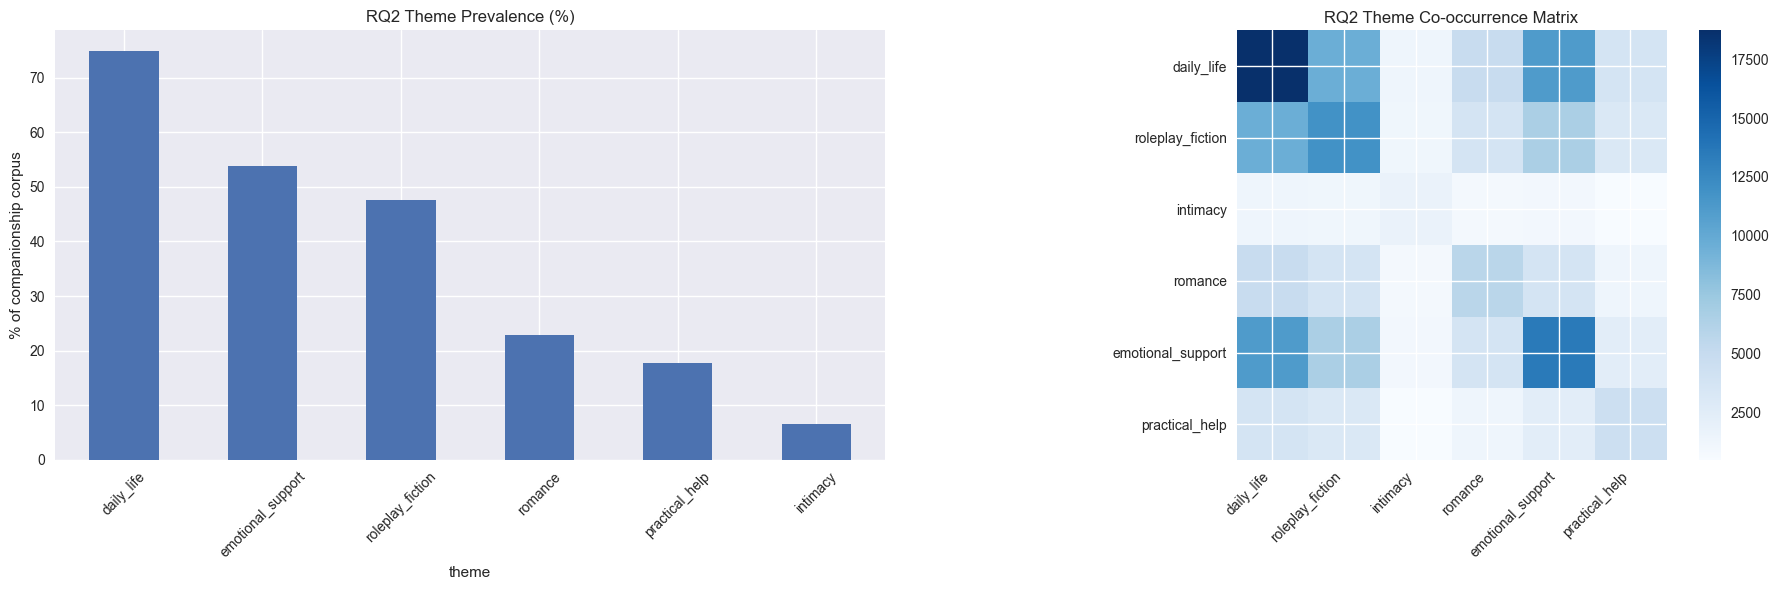

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rq2_theme_table.plot(kind='bar', x='theme', y='share_pct', ax=axes[0], legend=False, title='RQ2 Theme Prevalence (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('% of companionship corpus')

im = axes[1].imshow(cooccurrence.values, cmap='Blues')
axes[1].set_xticks(range(len(themes)))
axes[1].set_xticklabels(themes, rotation=45, ha='right')
axes[1].set_yticks(range(len(themes)))
axes[1].set_yticklabels(themes)
axes[1].set_title('RQ2 Theme Co-occurrence Matrix')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

# RQ3. How are human-AI relationships similar to or different from human-human relationships in terms of reciprocity, frequency of interaction, and emotional dynamics?

## Methodology

This section uses conversation-level proxies rather than direct longitudinal user histories.

Proxies measured:
- question asking
- affection signals
- continuity markers
- emotional-language markers
- intimacy markers
- self-disclosure markers

These are imperfect, but they make relational performance measurable.


In [32]:
AFFECTION_PATTERN = re.compile(r'\b(love|miss you|dear|sweetheart|baby|darling|beloved|xoxo)\b|[❤❤️]', re.I)
CONTINUITY_PATTERN = re.compile(r'\b(again|back|last time|remember when|as always|every day|daily|missed you|good to see you again|welcome back)\b', re.I)
EMOTION_PATTERN = re.compile(r'\b(sad|lonely|anxious|depressed|stress|cry|hurt|afraid|panic|overwhelm|comfort|support|reassure)\b', re.I)
INTIMACY_PATTERN = re.compile(r'\b(kiss|sex|naked|cuddle|intimate|touch|horny|make love|orgasm|erotic)\b', re.I)
SELF_DISCLOSURE_PATTERN = re.compile(r"\b(i feel|i am|i'm|my day|my life|my family|my boyfriend|my girlfriend|my husband|my wife)\b", re.I)


def compute_relationship_proxies(frame: pd.DataFrame) -> pd.Series:
    return pd.Series({
        'user_questions_pct': round(frame['user_text'].fillna('').str.contains(r'\?', regex=True).mean() * 100, 1),
        'assistant_questions_pct': round(frame['assistant_text'].fillna('').str.contains(r'\?', regex=True).mean() * 100, 1),
        'user_affection_pct': round(frame['user_text'].fillna('').apply(lambda text: bool(AFFECTION_PATTERN.search(text))).mean() * 100, 1),
        'assistant_affection_pct': round(frame['assistant_text'].fillna('').apply(lambda text: bool(AFFECTION_PATTERN.search(text))).mean() * 100, 1),
        'continuity_cues_pct': round(frame.apply(lambda row: bool(CONTINUITY_PATTERN.search(row['user_text'] or '') or CONTINUITY_PATTERN.search(row['assistant_text'] or '')), axis=1).mean() * 100, 1),
        'emotion_cues_pct': round(frame.apply(lambda row: bool(EMOTION_PATTERN.search(row['user_text'] or '') or EMOTION_PATTERN.search(row['assistant_text'] or '')), axis=1).mean() * 100, 1),
        'intimacy_cues_pct': round(frame.apply(lambda row: bool(INTIMACY_PATTERN.search(row['user_text'] or '') or INTIMACY_PATTERN.search(row['assistant_text'] or '')), axis=1).mean() * 100, 1),
        'user_self_disclosure_pct': round(frame['user_text'].fillna('').apply(lambda text: bool(SELF_DISCLOSURE_PATTERN.search(text))).mean() * 100, 1),
        'assistant_self_disclosure_pct': round(frame['assistant_text'].fillna('').apply(lambda text: bool(SELF_DISCLOSURE_PATTERN.search(text))).mean() * 100, 1),
    })


rq3_overall = compute_relationship_proxies(companionship_df)
rq3_overall.to_frame('pct_of_conversations')

,pct_of_conversations
user_questions_pct,49.2
assistant_questions_pct,68.2
user_affection_pct,37.7
assistant_affection_pct,58.5
continuity_cues_pct,60.7
emotion_cues_pct,57.0
intimacy_cues_pct,12.4
user_self_disclosure_pct,14.7
assistant_self_disclosure_pct,53.1


In [33]:
support_subset = companionship_df[companionship_df['rq_dominant_topic'] == 'emotional_support']
romance_subset = companionship_df[companionship_df['rq_dominant_topic'] == 'romance']
intimacy_subset = companionship_df[companionship_df['rq_dominant_topic'] == 'intimacy']

rq3_comparison = pd.DataFrame({
    'all_companionship': compute_relationship_proxies(companionship_df),
    'support_dominant': compute_relationship_proxies(support_subset) if len(support_subset) else pd.Series(dtype=float),
    'romance_dominant': compute_relationship_proxies(romance_subset) if len(romance_subset) else pd.Series(dtype=float),
    'intimacy_dominant': compute_relationship_proxies(intimacy_subset) if len(intimacy_subset) else pd.Series(dtype=float),
}).T

rq3_comparison

,user_questions_pct,assistant_questions_pct,user_affection_pct,assistant_affection_pct,continuity_cues_pct,emotion_cues_pct,intimacy_cues_pct,user_self_disclosure_pct,assistant_self_disclosure_pct
all_companionship,49.2,68.2,37.7,58.5,60.7,57.0,12.4,14.7,53.1
support_dominant,55.7,70.7,48.0,69.1,65.6,91.0,13.1,16.9,58.5
romance_dominant,27.2,63.2,30.5,62.0,57.3,15.4,19.2,11.4,52.9
intimacy_dominant,20.0,53.3,19.1,40.0,55.9,13.6,90.1,4.8,42.3


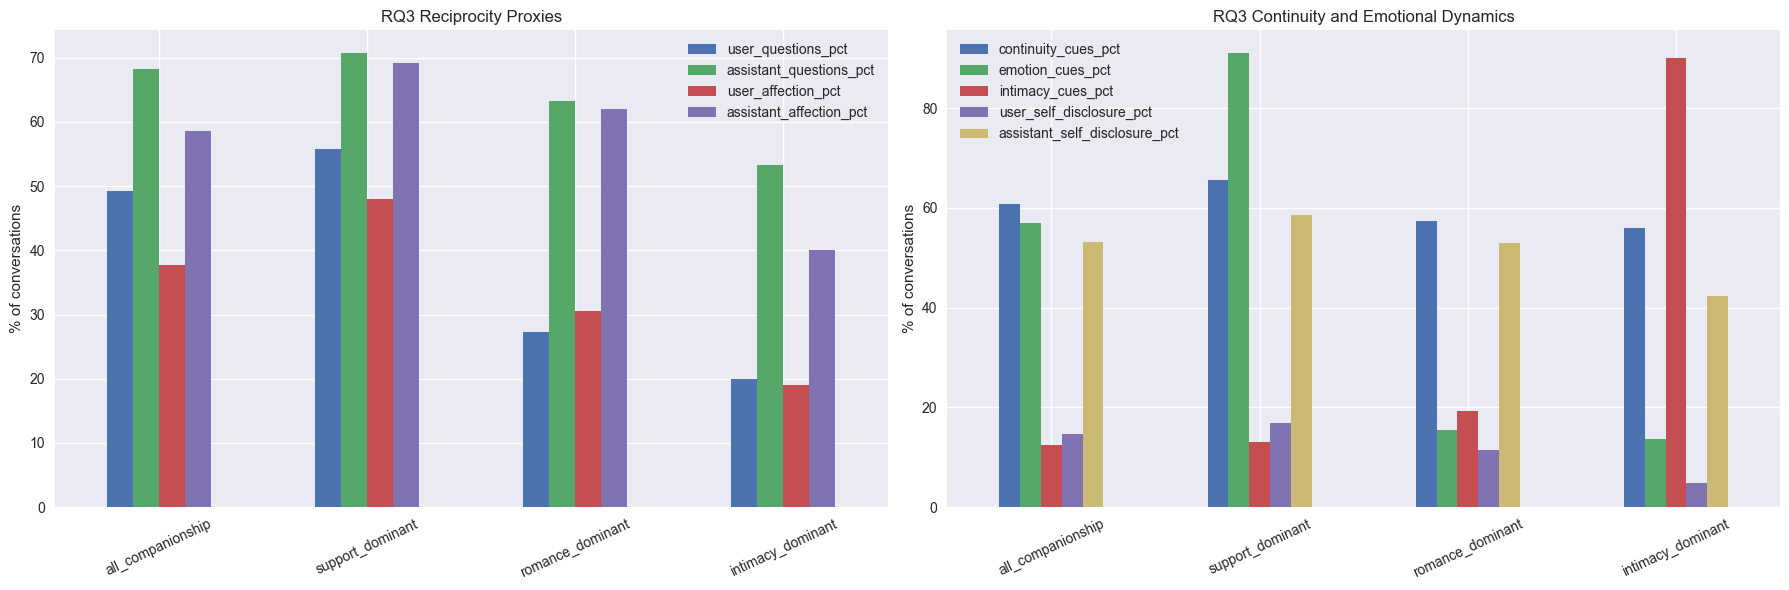

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rq3_comparison[['user_questions_pct', 'assistant_questions_pct', 'user_affection_pct', 'assistant_affection_pct']].plot(kind='bar', ax=axes[0], title='RQ3 Reciprocity Proxies')
axes[0].set_ylabel('% of conversations')
axes[0].tick_params(axis='x', rotation=25)

rq3_comparison[['continuity_cues_pct', 'emotion_cues_pct', 'intimacy_cues_pct', 'user_self_disclosure_pct', 'assistant_self_disclosure_pct']].plot(kind='bar', ax=axes[1], title='RQ3 Continuity and Emotional Dynamics')
axes[1].set_ylabel('% of conversations')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()

## Research summary tables


In [35]:
rq1_summary_table = rq1_dominant_table.copy()
rq1_summary_table['reading'] = rq1_summary_table['dominant_theme'].map({
    'emotional_support': 'Support, validation, reassurance, loneliness management',
    'romance': 'Partner framing and affection',
    'intimacy': 'Explicit sexual or intimate interactions',
    'roleplay_fiction': 'Performative and fictional relationship play',
    'daily_life': 'Ordinary routine conversation with relational framing',
    'practical_help': 'Instrumental tasks embedded inside relational use',
    'other': 'Mixed or weakly classifiable cases',
})

rq2_summary_table = rq1_theme_table.copy()

rq3_summary_table = pd.DataFrame([
    {'dimension': 'Reciprocity', 'statistic': f"User questions {rq3_overall['user_questions_pct']}% vs assistant questions {rq3_overall['assistant_questions_pct']}%", 'interpretation': 'Assistant more often sustains the conversational flow'},
    {'dimension': 'Affection', 'statistic': f"User affection {rq3_overall['user_affection_pct']}% vs assistant affection {rq3_overall['assistant_affection_pct']}%", 'interpretation': 'Warmth is disproportionately supplied by the AI'},
    {'dimension': 'Continuity', 'statistic': f"Continuity cues in {rq3_overall['continuity_cues_pct']}% of conversations", 'interpretation': 'Many conversations are framed as ongoing or repeated'},
    {'dimension': 'Emotional dynamics', 'statistic': f"Emotion cues {rq3_overall['emotion_cues_pct']}% and intimacy cues {rq3_overall['intimacy_cues_pct']}%", 'interpretation': 'Emotional support appears more central than explicit intimacy'},
    {'dimension': 'Self-disclosure', 'statistic': f"User self-disclosure {rq3_overall['user_self_disclosure_pct']}% vs assistant self-disclosure {rq3_overall['assistant_self_disclosure_pct']}%", 'interpretation': 'The AI often performs pseudo-intimacy by mirroring personal disclosure'},
])

display(rq1_summary_table)
display(rq2_summary_table)
display(rq3_summary_table)

,dominant_theme,count,share_pct,reading
0,emotional_support,13466,53.9,"Support, validation, reassurance, loneliness management"
1,roleplay_fiction,3643,14.6,Performative and fictional relationship play
2,daily_life,3200,12.8,Ordinary routine conversation with relational framing
3,romance,2111,8.4,Partner framing and affection
4,other,1961,7.8,Mixed or weakly classifiable cases
5,intimacy,435,1.7,Explicit sexual or intimate interactions
6,practical_help,184,0.7,Instrumental tasks embedded inside relational use


,theme,count,share_pct
0,daily_life,18730,74.9
1,emotional_support,13466,53.9
2,roleplay_fiction,11878,47.5
3,romance,5737,22.9
4,practical_help,4448,17.8
5,intimacy,1636,6.5


,dimension,statistic,interpretation
0,Reciprocity,User questions 49.2% vs assistant questions 68.2%,Assistant more often sustains the conversational flow
1,Affection,User affection 37.7% vs assistant affection 58.5%,Warmth is disproportionately supplied by the AI
2,Continuity,Continuity cues in 60.7% of conversations,Many conversations are framed as ongoing or repeated
3,Emotional dynamics,Emotion cues 57.0% and intimacy cues 12.4%,Emotional support appears more central than explicit intimacy
4,Self-disclosure,User self-disclosure 14.7% vs assistant self-disclosure 53.1%,The AI often performs pseudo-intimacy by mirroring personal disclosure


# References

### Data Source

1. Zhao, W., et al. *WildChat: 1M ChatGPT Interaction Logs in the Wild*. Hugging Face dataset: `allenai/WildChat`.

### Core Software Libraries

2. Hugging Face `datasets` library for dataset access and streaming.
3. `pandas` for tabular data management and corpus-level analysis.
4. `scikit-learn` for linear classification, cosine-similarity scoring utilities, and NMF topic modeling.
5. `matplotlib` for visualization.
6. `sentence-transformers` for pretrained sentence embeddings used in the companionship detector.

### Methodological Foundations

7. Ratner, A., et al. (2017). *Snorkel: Rapid Training Data Creation with Weak Supervision*. VLDB.
8. Reimers, N., and Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*. EMNLP.
9. Salton, G., and Buckley, C. (1988). *Term-weighting approaches in automatic text retrieval*. Information Processing & Management.
10. Lee, D. D., and Seung, H. S. (1999). *Learning the parts of objects by non-negative matrix factorization*. Nature.
11. Aggarwal, C. C., and Zhai, C., eds. (2012). *Mining Text Data*. Springer.
